# Hessian Approximation Comparison — Digits Dataset (PyTorch)

Reproduces **KFAC**, **EKFAC**, exact Hessian, Gauss-Newton Hessian, and Fisher Information Matrix
in vanilla PyTorch, with cross-validation against *nngeometry* and a JAX reference implementation.

| | |
|---|---|
| **Model** | MLP(64 → 16 → 16 → 10), no bias, tanh activations |
| **Dataset** | `sklearn.load_digits()` — 1797 samples, 8×8 images, 10 classes |
| **Parameters** | 64×16 + 16×16 + 16×10 = **1 280** |

## Structure
| Part | Content |
|------|----------|
| **Part 1** | Correct G⊗A ordering derivation; multi-seed matrix / HVP / IHVP comparison |
| **Part 2** | Cross-validation against **nngeometry** |
| **Part 3** | Cross-validation against the **JAX/Flax** repository |
| **Part 4** | Wrong A⊗G ordering — degradation demonstration |


In [52]:
import warnings
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"font.size": 11})
torch.set_default_dtype(torch.float64)
print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.11.0+cu130


## Hyperparameters

| Name | Value | Meaning |
|------|-------|----------|
| `DIM_IN` | 64 | Flattened 8×8 image input |
| `DIM_OUT` | 10 | Number of digit classes |
| `HIDDEN_DIM` | [16, 16] | Two hidden layers |
| `N_SEEDS` | 5 | Random seeds for averaging |
| `MCMC_REPETITIONS` (K) | 1 | Pseudo-target samples per point for MCMC Fisher |
| `EPS` | 1e-4 | Eigenvalue threshold for pseudo-inverse |


In [53]:
DIM_IN = 64
DIM_OUT = 10
HIDDEN_DIM = [8] * 1
N_SEEDS = 3
MCMC_REPETITIONS = 1  # K
EPS = 1e-4


## Dataset

sklearn **digits**: 1797 greyscale 8×8 handwritten digit images (classes 0–9).
Pixel values are standardised to zero mean / unit variance before training.


In [54]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_np, y_np = digits.data.astype(np.float64), digits.target
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.1, random_state=45, stratify=y_np
)
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_test_np = scaler.transform(X_test_np)
X_train = torch.tensor(X_train_np, dtype=torch.float64)
X_test = torch.tensor(X_test_np, dtype=torch.float64)
y_train = torch.tensor(y_train_np, dtype=torch.long)
y_test = torch.tensor(y_test_np, dtype=torch.long)
print(
    f"Train: {X_train.shape}  Test: {X_test.shape}  Classes: {len(torch.unique(y_train))}"
)


Train: torch.Size([1617, 64])  Test: torch.Size([180, 64])  Classes: 10


## Model Architecture

A simple feed-forward MLP with **no bias** and **tanh** activations:

$$\mathbf{h}^{(0)} = \mathbf{x} \in \mathbb{R}^{64}$$

$$\mathbf{h}^{(l)} = \tanh\!\bigl(W^{(l)}\,\mathbf{h}^{(l-1)}\bigr), \quad l = 1, 2$$

$$\mathbf{f}(\mathbf{x}) = W^{(3)}\,\mathbf{h}^{(2)} \in \mathbb{R}^{10}$$



In [55]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        dims = [input_dim] + hidden_dims + [output_dim]
        self.layers = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1], bias=False) for i in range(len(dims) - 1)]
        )

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = torch.tanh(x)
        return x


def train_model(model, seed=3, epochs=100, lr=0.03, batch_size=32):
    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    for _ in range(epochs):
        model.train()
        for Xb, yb in loader:
            opt.zero_grad()
            F.cross_entropy(model(Xb), yb).backward()
            opt.step()
    model.eval()


## Utility / Metric Functions

### Helper: Block-diagonal extraction

`extract_block_diagonal(H, model)` zeros out all off-block entries of a square matrix $H$, retaining only the per-parameter diagonal blocks. The block sizes are determined by the number of elements in each parameter tensor $p \in \text{model.parameters()}$, so for parameters with sizes $n_1, n_2, \ldots$:

$$H_{\text{bd}} = \bigoplus_{i} H[o_i : o_i + n_i,\; o_i : o_i + n_i], \qquad o_i = \sum_{j < i} n_j$$

### Matrix metrics

**Relative Frobenius error** ($A$ = reference, $B$ = approximation):
$$\text{RelFrob}(A,B) = \frac{\|A - B\|_F}{\max(\|A\|_F,\;\varepsilon)}$$

**Cosine similarity** (flattened matrices):
$$\text{cos}(A,B) = \frac{\operatorname{vec}(A)^\top \operatorname{vec}(B)}{\|\operatorname{vec}(A)\|\,\|\operatorname{vec}(B)\| + \varepsilon}$$

### Vector metrics (row-wise over batch $V \in \mathbb{R}^{B \times P}$)

**Relative error** — mean $\ell_2$ deviation normalised by reference norm:
$$\text{RelErr}(V_{\text{ref}}, V_{\text{approx}}) = \mathbb{E}_i\!\left[\frac{\|v_{\text{approx},i} - v_{\text{ref},i}\|}{\max(\|v_{\text{ref},i}\|, \varepsilon)}\right]$$

**Cosine similarity** — mean alignment per row:
$$\text{VecCos}(V_{\text{ref}}, V_{\text{approx}}) = \mathbb{E}_i\!\left[\frac{v_{\text{ref},i}^\top v_{\text{approx},i}}{\|v_{\text{ref},i}\|\,\|v_{\text{approx},i}\| + \varepsilon}\right]$$

**Absolute inner-product difference** — raw influence score deviation given query $X$:
$$\text{AbsIP}(V_{\text{ref}}, V_{\text{approx}}, X) = \mathbb{E}_i\!\left[\,|\langle x_i, v_{\text{approx},i}\rangle - \langle x_i, v_{\text{ref},i}\rangle|\,\right]$$

**Relative inner-product difference** — key metric for influence functions, measuring how much IHVP error propagates into the influence score $\langle x, H^{-1}v\rangle$:
$$\text{RelIP}(V_{\text{ref}}, V_{\text{approx}}, X) = \mathbb{E}_i\!\left[\frac{|\langle x_i, v_{\text{approx},i}\rangle - \langle x_i, v_{\text{ref},i}\rangle|}{\max(|\langle x_i, v_{\text{ref},i}\rangle|,\;\varepsilon)}\right]$$

### Round-trip error

Validates $H\hat{H}^{-1}v \approx v$ (pseudo-inverse quality). Given precomputed vectors $\hat{H}^{-1}V$, it applies $H$ via a right-multiply and measures the residual:

$$\text{RT}(V,\; \hat{H}^{-1}V,\; H) = \mathbb{E}_i\!\left[\frac{\|(\hat{H}^{-1}v_i)\,H - v_i\|^2}{\|v_i\|^2}\right]$$

> Note: the implementation uses `H_inv_v @ H.T`, so $H$ is applied on the right to row vectors — equivalent to the column-vector form $H^\top \hat{H}^{-1}v$ — which is consistent if $H$ is symmetric (as a Hessian is).

### Solvers

**`inv_ihvp(H, V, lam)`** — exact IHVP via a regularised linear solve:
$$\hat{H}^{-1}V^\top = (H + \lambda I)^{-1} V^\top$$

**`_pi_full(H, V)`** — pseudo-inverse IHVP via eigendecomposition, discarding near-zero eigenvalues (threshold $\varepsilon$):
$$\hat{H}^{+}V^\top = Q \operatorname{diag}(\tilde\lambda^{-1}) Q^\top V^\top, \qquad \tilde\lambda_k^{-1} = \begin{cases} 1/\lambda_k & |\lambda_k| > \varepsilon \\ 0 & \text{otherwise}\end{cases}$$

In [56]:
def extract_block_diagonal(H, model):
    H_bd, offset = torch.zeros_like(H), 0
    for p in model.parameters():
        n = p.numel()
        H_bd[offset : offset + n, offset : offset + n] = H[
            offset : offset + n, offset : offset + n
        ]
        offset += n
    return H_bd


def relative_frobenius_error(ref, approx):
    return ((ref - approx).norm("fro") / ref.norm("fro").clamp(min=1e-12)).item()


def cosine_similarity(A, B):
    a, b = A.flatten(), B.flatten()
    return (a @ b / (a.norm() * b.norm() + 1e-12)).item()


def vec_relative_error(ref, approx):
    return (
        ((approx - ref).norm(dim=-1) / ref.norm(dim=-1).clamp(min=1e-12)).mean().item()
    )


def vec_cosine_similarity(ref, approx):
    return (
        ((approx * ref).sum(-1) / (approx.norm(dim=-1) * ref.norm(dim=-1) + 1e-12))
        .mean()
        .item()
    )


def vec_inner_product_diff(ref, approx, query):
    return ((query * approx).sum(-1) - (query * ref).sum(-1)).abs().mean().item()


def vec_relative_inner_product_diff(ref, approx, query):
    ip_ref = (query * ref).sum(-1).abs().clamp(min=1e-12)
    ip_diff = ((query * approx).sum(-1) - (query * ref).sum(-1)).abs()
    return (ip_diff / ip_ref).mean().item()


def round_trip_error(v, H_inv_v, H, eps=1e-20):
    # Apply H (consistent with row-vector convention)
    Hv = H_inv_v @ H

    # Residual
    residual = Hv - v

    # Squared norms
    num = torch.norm(residual, dim=-1) ** 2
    denom = torch.norm(v, dim=-1) ** 2

    # Avoid division by zero
    rel_error = num / denom.clamp(min=eps)

    return rel_error.mean().item()


def inv_ihvp(H, V, lam=0.0):
    I_mat = torch.eye(H.shape[0], dtype=H.dtype)
    return torch.linalg.solve(H + lam * I_mat, V.T).T


def _pi_full(H, V):
    lm, Q = torch.linalg.eigh(H)
    inv = torch.where(lm.abs() > EPS, 1.0 / lm, torch.zeros_like(lm))
    return (V @ Q) * inv @ Q.T


---
# Part 1 — Hessian Approximations with Correct G⊗A Ordering

## 1.1 Why G⊗A is the Correct Kronecker Order for PyTorch

Understanding the ordering requires careful attention to how PyTorch stores and flattens weights.

**PyTorch weight layout.**  A linear layer stores $W \in \mathbb{R}^{O \times I}$ in **row-major** (C-order) memory, so:
$$W.\text{flatten()} = [W_{0,0},\, W_{0,1},\, \ldots,\, W_{O-1,I-1}] \equiv \operatorname{vec}(W^\top)$$

**Per-sample gradient.**  For sample $n$ with input activation $a_n \in \mathbb{R}^I$ and pre-activation gradient $g_n \in \mathbb{R}^O$ (gradient of loss w.r.t. layer pre-activation), the weight gradient is:
$$\nabla_W \mathcal{L}_n = g_n a_n^\top \in \mathbb{R}^{O \times I}$$

In PyTorch's flat row-major representation:
$$\nabla_W \mathcal{L}_n\big|_{\text{flat}} = g_n \otimes a_n \in \mathbb{R}^{OI}$$

*(For vectors, $g \otimes a = [g_0 a_0, g_0 a_1, \ldots, g_{O-1} a_{I-1}]$, which exactly matches row-major storage of $ga^\top$.)*

**Covariance / Fisher block:**
$$\operatorname{Cov}\!\left[\nabla_W \mathcal{L}\big|_{\text{flat}}\right] = \mathbb{E}[g g^\top] \otimes \mathbb{E}[a a^\top] = G \otimes A$$

where $A = \mathbb{E}[aa^\top] \in \mathbb{R}^{I\times I}$ and $G = \mathbb{E}[gg^\top] \in \mathbb{R}^{O\times O}$.

> **The correct KFAC block for PyTorch is $G \otimes A$ (not $A \otimes G$).**

**JAX/Flax** stores kernels as $(I,O)$, so its flat gradient is $a \otimes g$ and the KFAC block is $A \otimes G$ — opposite order, but internally consistent.


## 1.2 Exact Hessian

The exact Hessian of the (averaged) cross-entropy loss $\mathcal{L}$ w.r.t. the full parameter vector $\theta \in \mathbb{R}^P$:

$$H_{ij} = \frac{\partial^2 \mathcal{L}}{\partial \theta_i\, \partial \theta_j}$$

**Cost:** $\mathcal{O}(P)$ backward passes — one per row of $H$. For our model ($P=1280$) this is feasible but slow.

$H$ is symmetric, but **not necessarily PSD** — it includes second-order model curvature terms that can be negative.


In [57]:
def compute_exact_hessian(model, X, y):
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    out = model(X)
    loss = F.cross_entropy(out, y)
    grads = torch.autograd.grad(loss, params, create_graph=True)
    grad_flat = torch.cat([g.flatten() for g in grads])
    H = torch.zeros(P, P)
    for i in range(P):
        g2 = torch.autograd.grad(
            grad_flat[i], params, retain_graph=(i < P - 1), allow_unused=True
        )
        H[i] = torch.cat(
            [
                g.flatten() if g is not None else torch.zeros(p.numel())
                for g, p in zip(g2, params)
            ]
        ).detach()
    return H


## 1.3 Gauss-Newton Hessian (GNH) and Fisher Information Matrix

### Gauss-Newton Hessian
The GNH keeps only the first-order (Jacobian) term and drops model-curvature terms:

$$\text{GNH} = \frac{1}{N} \sum_{n=1}^N J_n^\top\, H_z^{(n)}\, J_n$$

where:
- $J_n \in \mathbb{R}^{C \times P}$ — Jacobian of logits w.r.t. parameters for sample $n$
- $H_z^{(n)} = \operatorname{diag}(p_n) - p_n p_n^\top \in \mathbb{R}^{C \times C}$ — Hessian of cross-entropy w.r.t. logits
- $p_n = \operatorname{softmax}(f_\theta(x_n))$ — predicted probabilities

The GNH is always **positive semi-definite** because $H_z^{(n)} \succeq 0$.

### True Fisher Information Matrix
Uses the model's own distribution $p(y|x)$ rather than true labels:

$$F = \frac{1}{N} \sum_{n=1}^N \sum_{c=1}^C p(c|x_n)\,\nabla_\theta \log p(c|x_n)\,[\nabla_\theta \log p(c|x_n)]^\top$$

For a softmax classifier: **GNH = FIM** (they are equal).

### MCMC Approximation of the Fisher
The exact FIM requires $C$ backward passes per sample. The MCMC variant draws $K$ class labels i.i.d. from $p(\cdot|x_n)$:

$$\hat{F}_{\text{MCMC}} = \frac{1}{NK} \sum_{n=1}^N \sum_{k=1}^K
\nabla_\theta \log p(\tilde{y}_{n,k}|x_n)\,[\nabla_\theta \log p(\tilde{y}_{n,k}|x_n)]^\top,\quad \tilde{y}_{n,k} \sim p(\cdot|x_n)$$


In [58]:
def compute_gnh(model, X, y):
    n, C = X.shape[0], 10
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    GNH = torch.zeros(P, P)
    for i in range(n):
        xi = X[i : i + 1]
        with torch.no_grad():
            p_i = torch.softmax(model(xi), dim=1).squeeze()
        H_z = torch.diag(p_i) - torch.outer(p_i, p_i)
        logits_i = model(xi)
        J = torch.zeros(C, P)
        for c in range(C):
            g2 = torch.autograd.grad(
                logits_i[0, c], params, retain_graph=(c < C - 1), allow_unused=True
            )
            J[c] = torch.cat(
                [
                    g.flatten() if g is not None else torch.zeros(p.numel())
                    for g, p in zip(g2, params)
                ]
            ).detach()
        GNH += J.T @ H_z @ J
    return GNH / n


def compute_true_fisher(model, X):
    n = X.shape[0]
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    FIM = torch.zeros(P, P)
    for i in range(n):
        xi = X[i : i + 1]
        with torch.no_grad():
            probs = torch.softmax(model(xi), dim=1).squeeze()
        for c in range(len(probs)):
            loss = F.cross_entropy(model(xi), torch.tensor([c]))
            grads = torch.autograd.grad(loss, params, retain_graph=True)
            g = torch.cat([gv.flatten() for gv in grads]).detach()
            FIM += probs[c].item() * torch.outer(g, g)
    model.zero_grad()
    return FIM / n


def compute_true_fisher_mcmc(model, X, mcmc_repetitions=1, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    n = X.shape[0]
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    FIM = torch.zeros(P, P)
    for i in range(n):
        xi = X[i : i + 1]
        with torch.no_grad():
            probs = torch.softmax(model(xi), dim=1).squeeze()
        sampled = torch.multinomial(probs, mcmc_repetitions, replacement=True)
        for c in sampled:
            loss = F.cross_entropy(model(xi), c.unsqueeze(0))
            grads = torch.autograd.grad(loss, params, retain_graph=True)
            g = torch.cat([gv.flatten() for gv in grads]).detach()
            FIM += torch.outer(g, g)
    model.zero_grad()
    return FIM / (n * mcmc_repetitions)


## 1.4 K-FAC — Kronecker-Factored Approximate Curvature

### Core Idea
For a linear layer $l$, the Fisher/GNH block is approximated as a Kronecker product:

$$B_l \approx G_l \otimes A_l$$

where the **activation covariance** and **gradient covariance** are:

$$A_l = \frac{1}{N}\sum_n \mathbb{E}_c\!\left[a_n^{(l)}\,(a_n^{(l)})^\top\right] \in \mathbb{R}^{I_l \times I_l}$$

$$G_l = \frac{1}{N}\sum_n \mathbb{E}_c\!\left[g_n^{(l)}\,(g_n^{(l)})^\top\right] \in \mathbb{R}^{O_l \times O_l}$$

$a_n^{(l)}$ = input activation to layer $l$ for sample $n$ (captured via forward hook)  
$g_n^{(l)}$ = gradient of loss w.r.t. layer $l$'s pre-activation (captured via backward hook)

### Collecting Statistics
We attach **forward** and **backward hooks** to each `nn.Linear` layer:
- Forward hook: captures $a_n^{(l)}$ (the input to the layer)
- Backward hook: captures $g_n^{(l)}$ (the gradient flowing back through the pre-activation)

The outer products $aa^\top$ and $gg^\top$ are accumulated over all samples and pseudo-target classes (either exact expectation or MCMC) to form $A_l$ and $G_l$.


In [59]:
class KFACCollector:
    def __init__(self, model):
        self.activations, self.gradients, self._hooks = {}, {}, []
        for name, mod in model.named_modules():
            if isinstance(mod, nn.Linear):
                self.activations[name] = []
                self.gradients[name] = []
                self._hooks.append(mod.register_forward_hook(self._fwd(name)))
                self._hooks.append(mod.register_full_backward_hook(self._bwd(name)))

    def _fwd(self, name):
        def hook(mod, inp, out):
            self.activations[name].append(inp[0].detach())

        return hook

    def _bwd(self, name):
        def hook(mod, gi, go):
            self.gradients[name].append(go[0].detach())

        return hook

    @property
    def layer_names(self):
        return list(self.activations.keys())

    def clear(self):
        for k in self.activations:
            self.activations[k] = []
            self.gradients[k] = []

    def remove(self):
        for h in self._hooks:
            h.remove()


def compute_kfac_factors(model, X, mcmc_repetitions=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    N, C = X.shape[0], 10
    coll = KFACCollector(model)
    A_sum = {k: None for k in coll.layer_names}
    G_sum = {k: None for k in coll.layer_names}
    for i in range(N):
        xi = X[i : i + 1]
        with torch.no_grad():
            probs = torch.softmax(model(xi), dim=1).squeeze()
        cw = (
            [(c, probs[c].item()) for c in range(C)]
            if mcmc_repetitions is None
            else [
                (c.item(), 1.0)
                for c in torch.multinomial(probs, mcmc_repetitions, replacement=True)
            ]
        )
        for c, w in cw:
            model.zero_grad()
            coll.clear()
            F.cross_entropy(model(xi), torch.tensor([c])).backward()
            for name in coll.layer_names:
                a = coll.activations[name][0].squeeze(0)
                g = coll.gradients[name][0].squeeze(0)
                A_sum[name] = (
                    w * torch.outer(a, a)
                    if A_sum[name] is None
                    else A_sum[name] + w * torch.outer(a, a)
                )
                G_sum[name] = (
                    w * torch.outer(g, g)
                    if G_sum[name] is None
                    else G_sum[name] + w * torch.outer(g, g)
                )
    coll.remove()
    model.zero_grad()
    norm = N if mcmc_repetitions is None else N * mcmc_repetitions
    A_covs = {k: (v + v.T) / (2 * norm) for k, v in A_sum.items()}
    G_covs = {k: (v + v.T) / (2 * norm) for k, v in G_sum.items()}
    return A_covs, G_covs


def kfac_full_matrix(model, A_covs, G_covs):
    P = sum(p.numel() for p in model.parameters())
    H, offset = torch.zeros(P, P), 0
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            sz = mod.weight.numel()
            H[offset : offset + sz, offset : offset + sz] = torch.kron(
                G_covs[name], A_covs[name]
            )
            offset += sz
    return H


def kfac_full_matrix_wrong(model, A_covs, G_covs):
    P = sum(p.numel() for p in model.parameters())
    H, offset = torch.zeros(P, P), 0
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear):
            sz = mod.weight.numel()
            H[offset : offset + sz, offset : offset + sz] = torch.kron(
                A_covs[name], G_covs[name]
            )  # wrong
            offset += sz
    return H


## 1.5 EK-FAC — Eigenvalue-Corrected KFAC

KFAC assumes $\mathbb{E}[(g\otimes a)(g\otimes a)^\top] \approx \mathbb{E}[gg^\top] \otimes \mathbb{E}[aa^\top]$. EK-FAC corrects for the residual correlation by working in the KFAC eigenbasis.

### Eigendecomposition of KFAC Factors
For each layer $l$, decompose the KFAC factors:

$$A_l = Q_A \Lambda_A Q_A^\top, \qquad G_l = Q_G \Lambda_G Q_G^\top$$

The eigenbasis for the full $(O_l I_l \times O_l I_l)$ KFAC block (using $G \otimes A$ ordering) is:
$$U = Q_G \otimes Q_A$$

### Eigenvalue Corrections
Instead of using $\lambda_G^{(i)} \lambda_A^{(j)}$ (the KFAC eigenvalue product, only approximate), EK-FAC directly estimates the true eigenvalue for each eigenvector $u_{ij} = q_G^{(i)} \otimes q_A^{(j)}$:

$$\Lambda^*[i,j] = \frac{1}{N}\sum_{n=1}^N \mathbb{E}_c\!\left[\left((Q_G^\top g_n)_i \cdot (Q_A^\top a_n)_j\right)^2\right]$$

Projection convention: $v \,@\, Q \equiv Q^\top v$ when $Q$ has orthonormal columns.
Shape: $\Lambda^* \in \mathbb{R}^{O \times I}$ — row index over $G$-eigenvectors, column index over $A$-eigenvectors.

### EK-FAC Inverse Hessian-Vector Product
For a batch of vectors $V_l \in \mathbb{R}^{B \times O_l I_l}$:

$$\text{IHVP}_l(V_l) = \underbrace{\left(V_l\,(Q_G \otimes Q_A)\right)}_{\text{project}} \big/ \underbrace{(\Lambda^* + \lambda)}_{\text{scaled eigenvalues}} \cdot \underbrace{(Q_G \otimes Q_A)^\top}_{\text{unproject}}$$

In code: `(v_block @ Q) / (lam + damping) @ Q.T` where `Q = kron(Q_G, Q_A)`.

> Division is element-wise. $\lambda$ is a damping (Tikhonov regularisation) constant.


In [60]:
def compute_kfac_eigenvectors(A_covs, G_covs):
    Q_A, Q_G, lam_A, lam_G = {}, {}, {}, {}
    for name in A_covs:
        va, qa = torch.linalg.eigh(A_covs[name])
        vg, qg = torch.linalg.eigh(G_covs[name])
        Q_A[name], lam_A[name] = qa, va
        Q_G[name], lam_G[name] = qg, vg
    return Q_A, Q_G, lam_A, lam_G


def compute_ekfac_corrections(model, X, Q_A, Q_G, mcmc_repetitions=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    N, C = X.shape[0], 10
    coll = KFACCollector(model)
    corr_sum = {
        name: torch.zeros(mod.weight.shape, dtype=X.dtype)
        for name, mod in model.named_modules()
        if isinstance(mod, nn.Linear) and name in Q_A
    }
    for i in range(N):
        xi = X[i : i + 1]
        with torch.no_grad():
            probs = torch.softmax(model(xi), dim=1).squeeze()
        cw = (
            [(c, probs[c].item()) for c in range(C)]
            if mcmc_repetitions is None
            else [
                (c.item(), 1.0)
                for c in torch.multinomial(probs, mcmc_repetitions, replacement=True)
            ]
        )
        for c, w in cw:
            model.zero_grad()
            coll.clear()
            F.cross_entropy(model(xi), torch.tensor([c])).backward()
            for name in corr_sum:
                a = coll.activations[name][0].squeeze(0)
                g = coll.gradients[name][0].squeeze(0)
                a_tilde = a @ Q_A[name]  # (I,) = Q_A^T a
                g_tilde = g @ Q_G[name]  # (O,) = Q_G^T g
                corr_sum[name] += w * torch.outer(g_tilde, a_tilde) ** 2
    coll.remove()
    model.zero_grad()
    norm = N if mcmc_repetitions is None else N * mcmc_repetitions
    return {k: v / norm for k, v in corr_sum.items()}


def ekfac_full_matrix(model, Q_A, Q_G, corrections):
    P = sum(p.numel() for p in model.parameters())
    H, offset = torch.zeros(P, P), 0
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear) and name in Q_A:
            sz = mod.weight.numel()
            Q = torch.kron(Q_G[name], Q_A[name])  # G outer, A inner (correct)
            lam = corrections[name].flatten()
            H[offset : offset + sz, offset : offset + sz] = Q @ torch.diag(lam) @ Q.T
            offset += sz
    return H


In [61]:
# ── Wrong-ordering variants (used in Part 4) ──────────────────────────────
def compute_ekfac_corrections_wrong(
    model, X, Q_A, Q_G, mcmc_repetitions=None, seed=None
):
    if seed is not None:
        torch.manual_seed(seed)
    N, C = X.shape[0], 10
    coll = KFACCollector(model)
    corr_sum = {
        name: torch.zeros(mod.weight.shape[1], mod.weight.shape[0], dtype=X.dtype)
        for name, mod in model.named_modules()
        if isinstance(mod, nn.Linear) and name in Q_A
    }
    for i in range(N):
        xi = X[i : i + 1]
        with torch.no_grad():
            probs = torch.softmax(model(xi), dim=1).squeeze()
        cw = (
            [(c, probs[c].item()) for c in range(C)]
            if mcmc_repetitions is None
            else [
                (c.item(), 1.0)
                for c in torch.multinomial(probs, mcmc_repetitions, replacement=True)
            ]
        )
        for c, w in cw:
            model.zero_grad()
            coll.clear()
            F.cross_entropy(model(xi), torch.tensor([c])).backward()
            for name in corr_sum:
                a = coll.activations[name][0].squeeze(0)
                g = coll.gradients[name][0].squeeze(0)
                a_tilde = Q_A[name] @ a  # wrong: Q@v instead of v@Q
                g_tilde = Q_G[name] @ g
                corr_sum[name] += w * torch.outer(a_tilde, g_tilde) ** 2
    coll.remove()
    model.zero_grad()
    norm = N if mcmc_repetitions is None else N * mcmc_repetitions
    return {k: v / norm for k, v in corr_sum.items()}


def ekfac_full_matrix_wrong(model, Q_A, Q_G, corrections):
    P = sum(p.numel() for p in model.parameters())
    H, offset = torch.zeros(P, P), 0
    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear) and name in Q_A:
            sz = mod.weight.numel()
            Q = torch.kron(Q_A[name], Q_G[name])  # A outer, G inner (wrong)
            lam = corrections[name].flatten()
            H[offset : offset + sz, offset : offset + sz] = Q @ torch.diag(lam) @ Q.T
            offset += sz
    return H


## 1.6 Multi-Seed Experiment

For each seed we:
1. Train a fresh MLP
2. Compute all Hessian approximations (exact, GNH, FIM, KFAC, EKFAC — exact and MCMC variants)
3. Draw 300 test vectors $V_1$ and 300 query vectors $V_2$ (both per-sample training gradients)
4. Evaluate matrix metrics, HVP, IHVP, pseudo-inverse round-trip, and a damping sweep

**Damping**: set to $\lambda = 0.1 \times \bar{|\lambda_i(H)|}$ (10% of the mean absolute eigenvalue of the exact Hessian).


In [62]:
def run_experiment(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = MLP(DIM_IN, HIDDEN_DIM, DIM_OUT)
    train_model(model, seed=seed)
    print(f"  Seed {seed}: ", end="", flush=True)
    X_h, y_h = X_train.clone(), y_train.clone()
    N, P = X_h.shape[0], sum(p.numel() for p in model.parameters())
    K = MCMC_REPETITIONS

    print("H..", end="", flush=True)
    H_exact = compute_exact_hessian(model, X_h, y_h)
    H_gnh = compute_gnh(model, X_h, y_h)
    H_fim = compute_true_fisher(model, X_h)
    H_fim_mcmc = compute_true_fisher_mcmc(model, X_h, mcmc_repetitions=K, seed=seed)

    print("KFAC..", end="", flush=True)
    A, G = compute_kfac_factors(model, X_h)
    A_mc, G_mc = compute_kfac_factors(model, X_h, mcmc_repetitions=K, seed=seed)
    H_kfac = kfac_full_matrix(model, A, G)
    H_kfac_mc = kfac_full_matrix(model, A_mc, G_mc)

    print("EKFAC..", end="", flush=True)
    QA, QG, lA, lG = compute_kfac_eigenvectors(A, G)
    QA_mc, QG_mc, _, _ = compute_kfac_eigenvectors(A_mc, G_mc)
    corr = compute_ekfac_corrections(model, X_h, QA, QG)
    corr_mc = compute_ekfac_corrections(
        model, X_h, QA_mc, QG_mc, mcmc_repetitions=K, seed=seed
    )
    H_ekfac = ekfac_full_matrix(model, QA, QG, corr)
    H_ekfac_mc = ekfac_full_matrix(model, QA_mc, QG_mc, corr_mc)

    H_bd = extract_block_diagonal(H_exact, model)
    H_fim_bd = extract_block_diagonal(H_fim, model)
    H_fim_mc_bd = extract_block_diagonal(H_fim_mcmc, model)

    params = list(model.parameters())
    n_vectors = 300
    torch.manual_seed(seed + 10_000)
    idx = torch.randperm(len(X_h))[: 2 * n_vectors]
    grad_rows = []
    for ii in idx:
        model.zero_grad()
        F.cross_entropy(model(X_h[ii : ii + 1]), y_h[ii : ii + 1]).backward()
        grad_rows.append(torch.cat([p.grad.flatten() for p in params]).detach())
    V1 = torch.stack(grad_rows)[:n_vectors]
    V2 = torch.stack(grad_rows)[n_vectors:]
    model.zero_grad()

    avg_eig = torch.linalg.eigvalsh(H_exact).abs().mean().item()
    d = avg_eig * 1e-1
    print(f"d={d:.3e}..", end="", flush=True)

    methods_mat = {
        "GNH": H_gnh,
        "True Fisher": H_fim,
        f"MCMC Fisher (K={K})": H_fim_mcmc,
        "Block Hessian": H_bd,
        "Block Fisher": H_fim_bd,
        f"Block Fisher MCMC (K={K})": H_fim_mc_bd,
        "KFAC": H_kfac,
        f"MCMC KFAC (K={K})": H_kfac_mc,
        "EKFAC": H_ekfac,
        f"MCMC EKFAC (K={K})": H_ekfac_mc,
    }
    mat_metrics = {
        nm: {
            "frob_vs_exact": relative_frobenius_error(H_exact, H),
            "frob_vs_fim": relative_frobenius_error(H_fim, H),
            "frob_vs_bd": relative_frobenius_error(H_bd, H),
            "cos_vs_bd": cosine_similarity(H_bd, H),
        }
        for nm, H in methods_mat.items()
    }

    hvp_exact = V1 @ H_exact.T
    hvp_gnh = V1 @ H_gnh.T
    hvp_metrics = {
        nm: {
            "rel_l2_vs_exact": vec_relative_error(hvp_exact, V1 @ H.T),
            "cos_vs_exact": vec_cosine_similarity(hvp_exact, V1 @ H.T),
            "rel_l2_vs_gnh": vec_relative_error(hvp_gnh, V1 @ H.T),
            "cos_vs_gnh": vec_cosine_similarity(hvp_gnh, V1 @ H.T),
            "ip_diff_vs_exact": vec_inner_product_diff(hvp_exact, V1 @ H.T, V2),
            "rel_ip_diff_vs_exact": vec_relative_inner_product_diff(
                hvp_exact, V1 @ H.T, V2
            ),
        }
        for nm, H in methods_mat.items()
    }

    print("IHVP..", end="", flush=True)
    ihvp_exact = inv_ihvp(H_exact, V1, 1e-15)
    ihvp_gnh = inv_ihvp(H_gnh, V1, d)
    ihvp_methods = {
        f"Identity (lambda_I)": V1 / d,
        "GNH": ihvp_gnh,
        "True Fisher": inv_ihvp(H_fim, V1, d),
        f"MCMC Fisher (K={K})": inv_ihvp(H_fim_mcmc, V1, d),
        "Block Hessian": inv_ihvp(H_bd, V1, d),
        "Block Fisher": inv_ihvp(H_fim_bd, V1, d),
        f"Block Fisher MCMC (K={K})": inv_ihvp(H_fim_mc_bd, V1, d),
        "KFAC": inv_ihvp(H_kfac, V1, d),
        f"MCMC KFAC (K={K})": inv_ihvp(H_kfac_mc, V1, d),
        "EKFAC": inv_ihvp(H_ekfac, V1, d),
        f"MCMC EKFAC (K={K})": inv_ihvp(H_ekfac_mc, V1, d),
    }
    ihvp_metrics = {
        nm: {
            "rel_l2_vs_exact": vec_relative_error(ihvp_exact, ih),
            "cos_vs_exact": vec_cosine_similarity(ihvp_exact, ih),
            "rel_l2_vs_gnh": vec_relative_error(ihvp_gnh, ih),
            "cos_vs_gnh": vec_cosine_similarity(ihvp_gnh, ih),
            "ip_diff": vec_inner_product_diff(ihvp_exact, ih, V2),
            "rel_ip_diff": vec_relative_inner_product_diff(ihvp_exact, ih, V2),
        }
        for nm, ih in ihvp_methods.items()
    }

    print("PI..", end="", flush=True)
    pi_methods = {
        "Exact": _pi_full(H_exact, V1),
        "GNH": _pi_full(H_gnh, V1),
        "True Fisher": _pi_full(H_fim, V1),
        f"MCMC Fisher (K={K})": _pi_full(H_fim_mcmc, V1),
        "Block Hessian": _pi_full(H_bd, V1),
        "Block Fisher": _pi_full(H_fim_bd, V1),
        "KFAC": _pi_full(H_kfac, V1),
        f"MCMC KFAC (K={K})": _pi_full(H_kfac_mc, V1),
        "EKFAC": _pi_full(H_ekfac, V1),
        f"MCMC EKFAC (K={K})": _pi_full(H_ekfac_mc, V1),
    }
    rt_metrics = {
        nm: round_trip_error(V1, ih, H_exact) for nm, ih in pi_methods.items()
    }

    print("sweep..", end="", flush=True)
    _dampings = np.logspace(-8, 0, 25)
    ihvp_exact_ref = inv_ihvp(H_exact, V1, 1e-15)
    _sweep = {
        "KFAC": H_kfac,
        f"MCMC KFAC (K={K})": H_kfac_mc,
        "EKFAC": H_ekfac,
        f"MCMC EKFAC (K={K})": H_ekfac_mc,
    }
    ds, dsi, dsri = (
        {nm: [] for nm in _sweep},
        {nm: [] for nm in _sweep},
        {nm: [] for nm in _sweep},
    )
    for d_ in _dampings:
        for nm, Hm in _sweep.items():
            ih = inv_ihvp(Hm, V1, float(d_))
            ds[nm].append(round_trip_error(V1, ih, H_exact))
            dsi[nm].append(vec_inner_product_diff(ihvp_exact_ref, ih, V2))
            dsri[nm].append(vec_relative_inner_product_diff(ihvp_exact_ref, ih, V2))

    print(" done.")
    return dict(
        seed=seed,
        damping=d,
        mat_metrics=mat_metrics,
        hvp_metrics=hvp_metrics,
        ihvp_metrics=ihvp_metrics,
        rt_metrics=rt_metrics,
        dampings=_dampings.tolist(),
        damping_sweep=ds,
        damping_sweep_ip=dsi,
        damping_sweep_rel_ip=dsri,
        model=model,
        H_exact=H_exact,
        H_gnh=H_gnh,
        H_fim=H_fim,
        H_fim_bd=H_fim_bd,
        H_kfac=H_kfac,
        H_ekfac=H_ekfac,
        H_bd=H_bd,
        QA=QA,
        QG=QG,
        lA=lA,
        lG=lG,
        corr=corr,
        A_covs=A,
        G_covs=G,
    )


In [63]:
print(f"Running {N_SEEDS} seeds ...")
results = [run_experiment(s + 5) for s in range(N_SEEDS)]


Running 3 seeds ...


  Seed 5: H..KFAC..EKFAC..d=2.479e-03..IHVP..PI..sweep.. done.
  Seed 6: H..KFAC..EKFAC..d=2.686e-03..IHVP..PI..sweep.. done.
  Seed 7: H..KFAC..EKFAC..d=2.924e-03..IHVP..PI..sweep.. done.


## 1.7 Statistical Results

Results are averaged over all seeds. We report **mean ± std** for:

| Metric | Description |
|--------|-------------|
| Frob vs Exact | $\|H_{\text{approx}} - H_{\text{exact}}\|_F / \|H_{\text{exact}}\|_F$ |
| HVP Rel-L2 vs Exact | Relative L2 error of $Hv$ compared to exact |
| HVP Cos vs Exact | Cosine similarity of $Hv$ vectors |
| IHVP Rel-L2 vs Exact | Relative L2 error of $H^{-1}v$ compared to exact |
| Rel IP Diff | Relative inner-product difference (influence function quality) |
| Pseudo-inv RT Error | Round-trip error $\|H \hat H^{-1} v - v\|^2 / \|v\|^2$ |


In [64]:
def _agg(results, group, metric_key):
    out = {}
    for nm in results[0][group]:
        vs = [r[group][nm].get(metric_key) for r in results]
        vs = [v for v in vs if v is not None]
        if vs:
            out[nm] = (np.mean(vs), np.std(vs))
    return out


def _fmt(m, s):
    return f"{m:.4f} +/- {s:.4f}"


K = MCMC_REPETITIONS
NMS = [
    "GNH",
    "True Fisher",
    f"MCMC Fisher (K={K})",
    "Block Hessian",
    "Block Fisher",
    f"Block Fisher MCMC (K={K})",
    "KFAC",
    f"MCMC KFAC (K={K})",
    "EKFAC",
    f"MCMC EKFAC (K={K})",
]

fe = _agg(results, "mat_metrics", "frob_vs_exact")
ff = _agg(results, "mat_metrics", "frob_vs_fim")
fb = _agg(results, "mat_metrics", "frob_vs_bd")
print(f"{'Method':<32} {'Frob vs Exact':>20} {'Frob vs FIM':>20} {'Frob vs BD':>20}")
print("-" * 94)
for nm in NMS:
    if nm in fe:
        print(
            f"{nm:<32} {_fmt(*fe[nm]):>20} {_fmt(*ff.get(nm, (0, 0))):>20} {_fmt(*fb.get(nm, (0, 0))):>20}"
        )

NMS_HVP = [
    "GNH",
    "True Fisher",
    f"MCMC Fisher (K={K})",
    "Block Hessian",
    "Block Fisher",
    "KFAC",
    f"MCMC KFAC (K={K})",
    "EKFAC",
    f"MCMC EKFAC (K={K})",
]
h_l2e = _agg(results, "hvp_metrics", "rel_l2_vs_exact")
h_cse = _agg(results, "hvp_metrics", "cos_vs_exact")
h_rip = _agg(results, "hvp_metrics", "rel_ip_diff_vs_exact")
print(
    f"\n{'Method':<32} {'HVP Rel-L2 vs Exact':>22} {'HVP Cos vs Exact':>20} {'Rel IP Diff':>14}"
)
print("-" * 90)
for nm in NMS_HVP:
    if nm in h_l2e:
        print(
            f"{nm:<32} {_fmt(*h_l2e[nm]):>22} {_fmt(*h_cse.get(nm, (0, 0))):>20} {_fmt(*h_rip.get(nm, (0, 0))):>14}"
        )

NMS_IHP = [f"Identity (lambda_I)"] + NMS_HVP
i_l2e = _agg(results, "ihvp_metrics", "rel_l2_vs_exact")
i_cse = _agg(results, "ihvp_metrics", "cos_vs_exact")
i_rip = _agg(results, "ihvp_metrics", "rel_ip_diff")
print(
    f"\n{'Method':<32} {'IHVP Rel-L2 vs Exact':>22} {'IHVP Cos vs Exact':>20} {'Rel IP Diff':>14}"
)
print("-" * 90)
for nm in NMS_IHP:
    if nm in i_l2e:
        print(
            f"{nm:<32} {_fmt(*i_l2e[nm]):>22} {_fmt(*i_cse.get(nm, (0, 0))):>20} {_fmt(*i_rip.get(nm, (0, 0))):>14}"
        )

rt2 = {}
for nm in [
    "Exact",
    "GNH",
    "True Fisher",
    f"MCMC Fisher (K={K})",
    "Block Hessian",
    "Block Fisher",
    "KFAC",
    f"MCMC KFAC (K={K})",
    "EKFAC",
    f"MCMC EKFAC (K={K})",
]:
    vs = [r["rt_metrics"].get(nm) for r in results if nm in r.get("rt_metrics", {})]
    if vs:
        rt2[nm] = (np.mean(vs), np.std(vs))
print(f"\n{'Method':<32} {'Pseudo-Inv RT Error':>22}")
print("-" * 56)
for nm, (m, s) in rt2.items():
    print(f"{nm:<32} {_fmt(m, s):>22}")


Method                                  Frob vs Exact          Frob vs FIM           Frob vs BD
----------------------------------------------------------------------------------------------
GNH                                 0.2726 +/- 0.0178    0.0000 +/- 0.0000    0.3295 +/- 0.0177
True Fisher                         0.2726 +/- 0.0178    0.0000 +/- 0.0000    0.3295 +/- 0.0177
MCMC Fisher (K=1)                   0.9413 +/- 0.0693    1.0943 +/- 0.0595    0.9795 +/- 0.0684
Block Hessian                       0.1857 +/- 0.0044    0.3852 +/- 0.0262    0.0000 +/- 0.0000
Block Fisher                        0.3270 +/- 0.0168    0.2143 +/- 0.0101    0.2737 +/- 0.0186
Block Fisher MCMC (K=1)             0.9381 +/- 0.0682    1.0904 +/- 0.0580    0.9356 +/- 0.0709
KFAC                                0.7045 +/- 0.0128    0.7491 +/- 0.0110    0.6916 +/- 0.0130
MCMC KFAC (K=1)                     0.7767 +/- 0.0154    0.8641 +/- 0.0233    0.7675 +/- 0.0166
EKFAC                               0.683

## 1.8 Plots

Bar charts (mean ± std over seeds) for HVP and IHVP quality metrics, pseudo-inverse round-trip error, and a **damping sweep** showing how round-trip and inner-product errors vary as $\lambda$ changes.


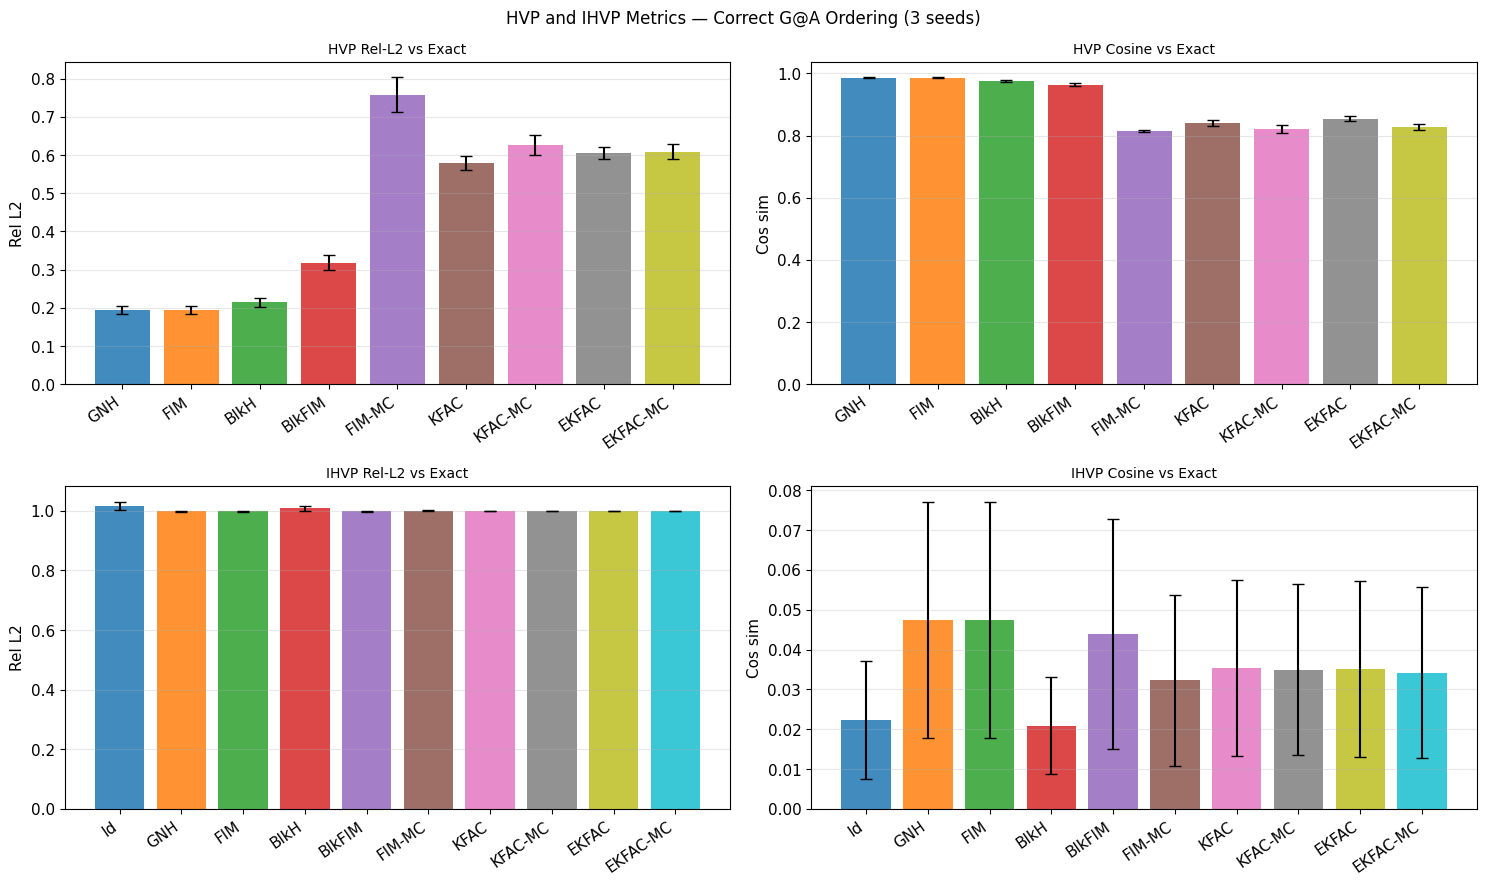

In [65]:
short = {
    "GNH": "GNH",
    "True Fisher": "FIM",
    f"MCMC Fisher (K={K})": "FIM-MC",
    "Block Hessian": "BlkH",
    "Block Fisher": "BlkFIM",
    f"Block Fisher MCMC (K={K})": "BlkFIM-MC",
    "KFAC": "KFAC",
    f"MCMC KFAC (K={K})": "KFAC-MC",
    "EKFAC": "EKFAC",
    f"MCMC EKFAC (K={K})": "EKFAC-MC",
    f"Identity (lambda_I)": "Id",
}


def _bar(ax, names, means, stds, title, ylabel, log_scale=False):
    x = np.arange(len(names))
    ax.bar(
        x,
        means,
        yerr=stds,
        capsize=4,
        color=[f"C{i}" for i in range(len(names))],
        alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([short.get(n, n) for n in names], rotation=35, ha="right")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    if log_scale:
        ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)


hvp_names = [
    "GNH",
    "True Fisher",
    "Block Hessian",
    "Block Fisher",
    f"MCMC Fisher (K={K})",
    "KFAC",
    f"MCMC KFAC (K={K})",
    "EKFAC",
    f"MCMC EKFAC (K={K})",
]
ihvp_names = [f"Identity (lambda_I)"] + hvp_names

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle(
    f"HVP and IHVP Metrics — Correct G@A Ordering ({N_SEEDS} seeds)", fontsize=12
)
for ax, names, group, key, title, ylabel in [
    (
        axes[0, 0],
        hvp_names,
        "hvp_metrics",
        "rel_l2_vs_exact",
        "HVP Rel-L2 vs Exact",
        "Rel L2",
    ),
    (
        axes[0, 1],
        hvp_names,
        "hvp_metrics",
        "cos_vs_exact",
        "HVP Cosine vs Exact",
        "Cos sim",
    ),
    (
        axes[1, 0],
        ihvp_names,
        "ihvp_metrics",
        "rel_l2_vs_exact",
        "IHVP Rel-L2 vs Exact",
        "Rel L2",
    ),
    (
        axes[1, 1],
        ihvp_names,
        "ihvp_metrics",
        "cos_vs_exact",
        "IHVP Cosine vs Exact",
        "Cos sim",
    ),
]:
    ms_, ss_, valid = [], [], []
    for nm in names:
        vs = [r[group].get(nm, {}).get(key) for r in results]
        vs = [v for v in vs if v is not None]
        if vs:
            valid.append(nm)
            ms_.append(np.mean(vs))
            ss_.append(np.std(vs))
    _bar(ax, valid, ms_, ss_, title, ylabel)
plt.tight_layout()
plt.show()


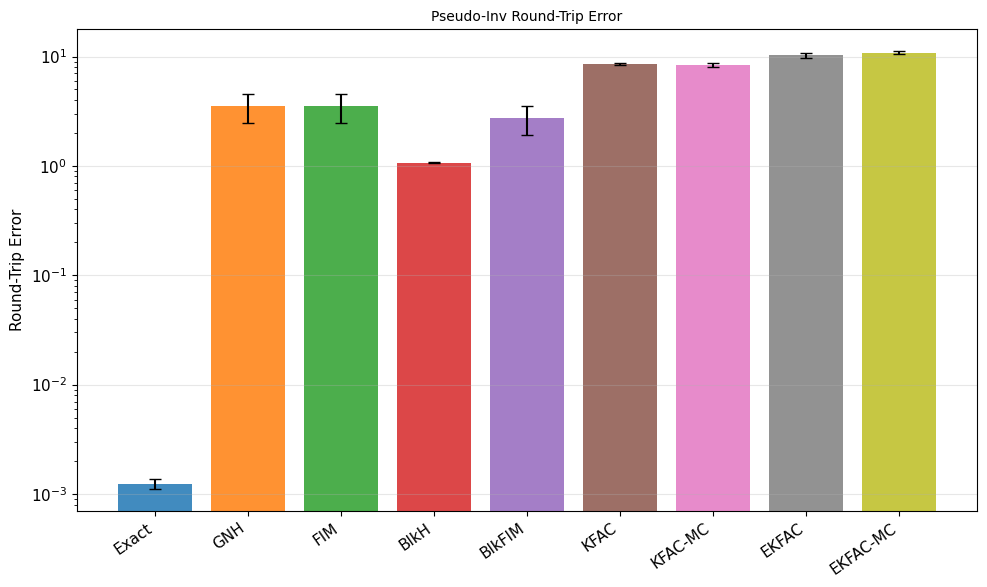

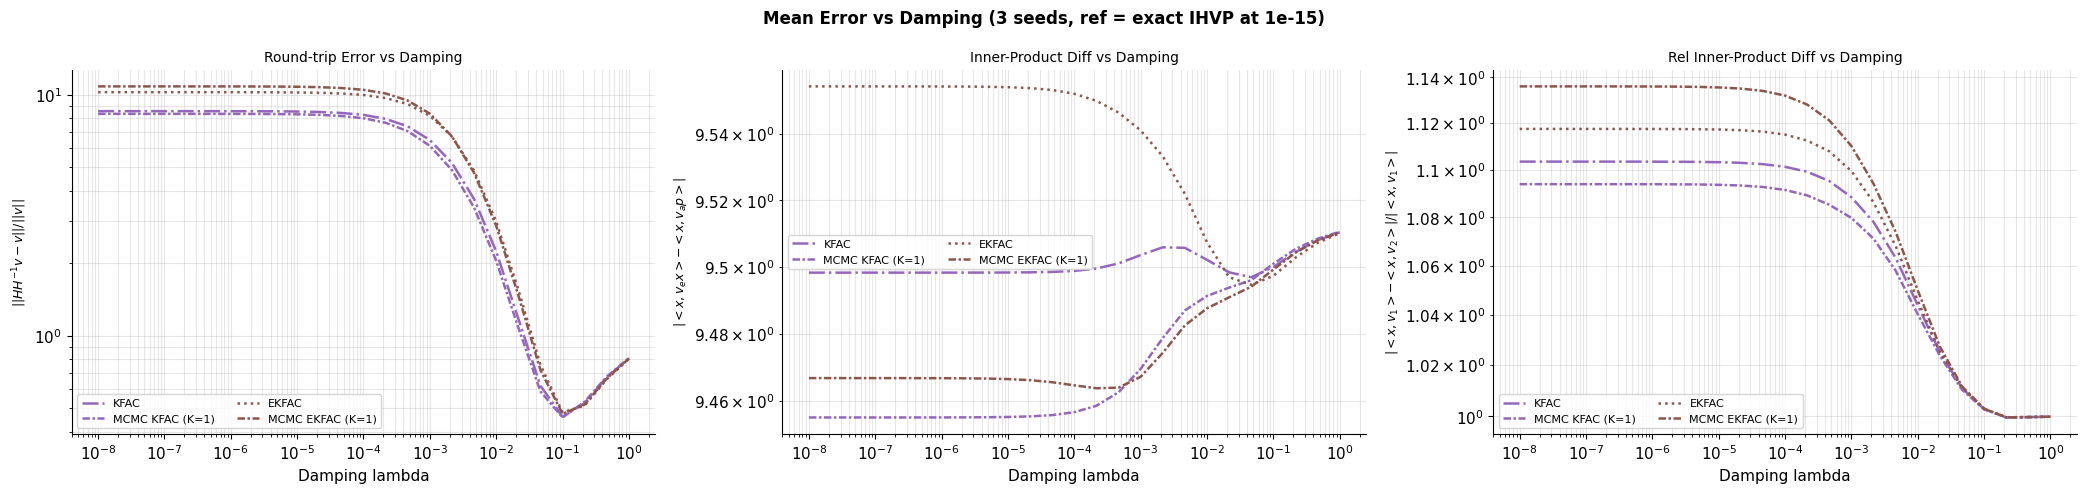

In [66]:
# Round-trip error bar
rt_names = [
    "Exact",
    "GNH",
    "True Fisher",
    "Block Hessian",
    "Block Fisher",
    "KFAC",
    f"MCMC KFAC (K={K})",
    "EKFAC",
    f"MCMC EKFAC (K={K})",
]
rt_means, rt_stds, valid_rt = [], [], []
for nm in rt_names:
    vs = [r["rt_metrics"].get(nm) for r in results if nm in r.get("rt_metrics", {})]
    if vs:
        valid_rt.append(nm)
        rt_means.append(np.mean(vs))
        rt_stds.append(np.std(vs))
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale("log")
_bar(ax, valid_rt, rt_means, rt_stds, "Pseudo-Inv Round-Trip Error", "Round-Trip Error")
plt.tight_layout()
plt.show()

# Damping sweep
styles_sweep = {
    "KFAC": ("-.", "C4"),
    f"MCMC KFAC (K={K})": ((0, (3, 1, 1, 1)), "C4"),
    "EKFAC": (":", "C5"),
    f"MCMC EKFAC (K={K})": ((0, (3, 1, 1, 1)), "C5"),
}
dampings_arr = np.array(results[0]["dampings"])
sweep_data, sweep_ip_data, sweep_ri_data = (
    defaultdict(list),
    defaultdict(list),
    defaultdict(list),
)
for r in results:
    for nm, vals in r["damping_sweep"].items():
        sweep_data[nm].append(vals)
    for nm, vals in r["damping_sweep_ip"].items():
        sweep_ip_data[nm].append(vals)
    for nm, vals in r["damping_sweep_rel_ip"].items():
        sweep_ri_data[nm].append(vals)

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle(
    f"Mean Error vs Damping ({len(results)} seeds, ref = exact IHVP at 1e-15)",
    fontsize=12,
    fontweight="bold",
)
for ax, data_dict, ylabel, title in [
    (axes[0], sweep_data, r"$||H H^{-1}v-v||/||v||$", "Round-trip Error vs Damping"),
    (axes[1], sweep_ip_data, r"$|<x,v_ex>-<x,v_ap>|$", "Inner-Product Diff vs Damping"),
    (
        axes[2],
        sweep_ri_data,
        r"$|<x,v_1>-<x,v_2>|/|<x,v_1>|$",
        "Rel Inner-Product Diff vs Damping",
    ),
]:
    for nm, all_runs in data_dict.items():
        arr = np.array(all_runs)
        mean, std = arr.mean(0), arr.std(0)
        ls, col = styles_sweep.get(nm, ("-", "gray"))
        ax.plot(dampings_arr, mean, linestyle=ls, color=col, label=nm, linewidth=1.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Damping lambda")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, which="both")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 1.9 Matrix Visualisation and Eigenvalue Spectra

Visual comparison of Hessian approximation matrices (seed 0), eigenvalue spectra, and EKFAC correction values vs KFAC Kronecker eigenvalue products.

**Key observation**: EKFAC corrections $\Lambda^*$ track the true eigenvalue spectrum much more closely than the KFAC product $\lambda_G^{(i)} \lambda_A^{(j)}$, especially for the largest eigenvalues that dominate the IHVP.


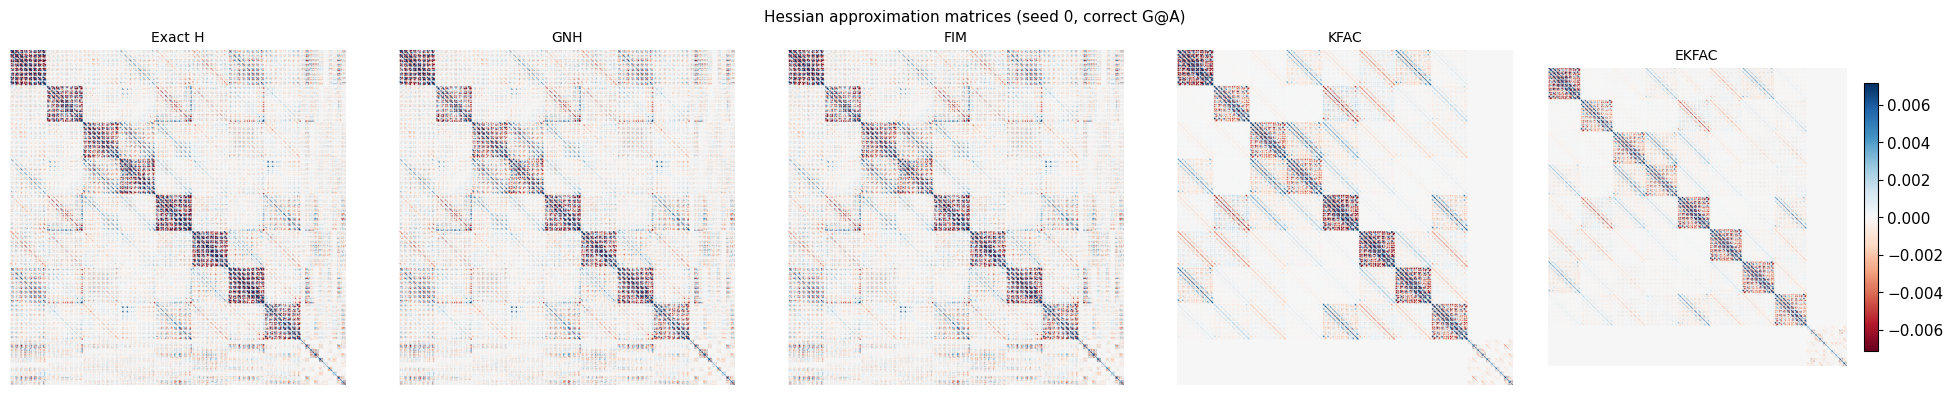

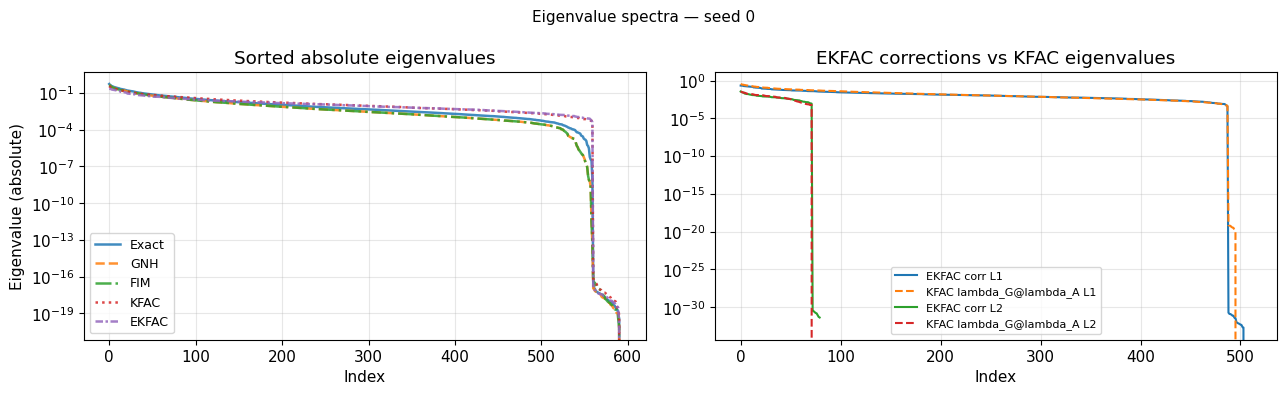

In [67]:
r0 = results[0]
items = [
    ("Exact H", r0["H_exact"]),
    ("GNH", r0["H_gnh"]),
    ("FIM", r0["H_fim"]),
    ("KFAC", r0["H_kfac"]),
    ("EKFAC", r0["H_ekfac"]),
]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
vmax = r0["H_exact"].abs().quantile(0.98).item()
for ax, (title, H) in zip(axes, items):
    im = ax.imshow(H.numpy(), cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.colorbar(im, ax=axes[-1], shrink=0.8)
fig.suptitle("Hessian approximation matrices (seed 0, correct G@A)", fontsize=11)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Eigenvalue spectra — seed 0", fontsize=11)
ax_eig = axes[0]
for title, H, ls in [
    ("Exact", r0["H_exact"], "-"),
    ("GNH", r0["H_gnh"], "--"),
    ("FIM", r0["H_fim"], "-."),
    ("KFAC", r0["H_kfac"], ":"),
    ("EKFAC", r0["H_ekfac"], (0, (3, 1, 1, 1))),
]:
    ev = torch.linalg.eigvalsh(H).numpy()
    ax_eig.semilogy(
        np.sort(np.abs(ev))[::-1], linestyle=ls, label=title, alpha=0.85, linewidth=1.8
    )
ax_eig.set_xlabel("Index")
ax_eig.set_ylabel("Eigenvalue (absolute)")
ax_eig.set_title("Sorted absolute eigenvalues")
ax_eig.legend(fontsize=9)
ax_eig.grid(alpha=0.3, which="both")

ax_corr = axes[1]
corr0, lA0, lG0 = r0["corr"], r0["lA"], r0["lG"]
for i, name in enumerate(corr0):
    c0 = np.sort(corr0[name].flatten().numpy())[::-1]
    lk = np.sort(torch.outer(lG0[name], lA0[name]).flatten().numpy())[::-1]
    ax_corr.semilogy(c0, label=f"EKFAC corr L{i + 1}", lw=1.5, color=f"C{2 * i}")
    ax_corr.semilogy(
        lk,
        label=f"KFAC lambda_G@lambda_A L{i + 1}",
        ls="--",
        lw=1.5,
        color=f"C{2 * i + 1}",
    )
ax_corr.set_xlabel("Index")
ax_corr.set_title("EKFAC corrections vs KFAC eigenvalues")
ax_corr.legend(fontsize=8)
ax_corr.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


---
# Part 2 — Cross-Framework Validation Against nngeometry

nngeometry is a PyTorch library for computing Fisher / GGN matrices. It uses the same **G⊗A** ordering as our corrected implementation.

| Convention | This notebook | nngeometry |
|------------|---------------|------------|
| KFAC block | kron(G, A) | kron(G, A) | ← both correct ✓ |
| EKFAC projection | v @ Q = Q^T v | v @ Q | ← both correct ✓ |

**Expected result:** near-zero Frobenius error for exact (all-classes) FIM, KFAC, and EKFAC. MCMC variants will differ due to different RNG seeds.


In [68]:
import os, sys

sys.path.insert(0, os.path.join(os.getcwd(), "nngeometry"))

try:
    from nngeometry import FIM, FIM_MonteCarlo
    from nngeometry.object import PMatDense, PMatEKFAC, PMatKFAC

    HAS_NN = True
    print("nngeometry imported.")
except ImportError as e:
    print(f"nngeometry not available ({e}) — skipping Part 2")
    HAS_NN = False


nngeometry not available (No module named 'nngeometry') — skipping Part 2


In [69]:
SEED_CMP = 0

if HAS_NN:
    r0 = results[0]
    model_cmp = r0["model"]
    X_cmp = X_train.clone()
    H_nb_fim = r0["H_fim"]
    H_nb_kfac = r0["H_kfac"]
    H_nb_ekfac = r0["H_ekfac"]
    QA_nb, QG_nb, corr_nb = r0["QA"], r0["QG"], r0["corr"]

    print("Computing MCMC PyTorch matrices ...")
    H_nb_fim_mc = compute_true_fisher_mcmc(
        model_cmp, X_cmp, mcmc_repetitions=MCMC_REPETITIONS, seed=SEED_CMP
    )
    A_nb_m, G_nb_m = compute_kfac_factors(
        model_cmp, X_cmp, mcmc_repetitions=MCMC_REPETITIONS, seed=SEED_CMP
    )
    H_nb_kfac_mc = kfac_full_matrix(model_cmp, A_nb_m, G_nb_m)
    QA_nb_m, QG_nb_m, _, _ = compute_kfac_eigenvectors(A_nb_m, G_nb_m)
    corr_nb_mc = compute_ekfac_corrections(
        model_cmp,
        X_cmp,
        QA_nb_m,
        QG_nb_m,
        mcmc_repetitions=MCMC_REPETITIONS,
        seed=SEED_CMP,
    )
    H_nb_ekfac_mc = ekfac_full_matrix(model_cmp, QA_nb_m, QG_nb_m, corr_nb_mc)
    print("  done.")

    loader_nn = DataLoader(
        TensorDataset(X_cmp, y_train), batch_size=len(X_cmp), shuffle=False
    )
    print("Computing nngeometry matrices ...")
    F_nn_fim = FIM(model_cmp, loader_nn, PMatDense, variant="classif_logits")
    H_nn_fim = F_nn_fim.to_torch()
    torch.manual_seed(SEED_CMP)
    F_nn_fim_mc = FIM_MonteCarlo(
        model_cmp,
        loader_nn,
        PMatDense,
        trials=MCMC_REPETITIONS,
        variant="classif_logits",
    )
    H_nn_fim_mc = F_nn_fim_mc.to_torch()
    F_nn_kfac = FIM(model_cmp, loader_nn, PMatKFAC, variant="classif_logits")
    H_nn_kfac = F_nn_kfac.to_torch()
    torch.manual_seed(SEED_CMP)
    F_nn_kfac_mc = FIM_MonteCarlo(
        model_cmp,
        loader_nn,
        PMatKFAC,
        trials=MCMC_REPETITIONS,
        variant="classif_logits",
    )
    H_nn_kfac_mc = F_nn_kfac_mc.to_torch()
    F_nn_ekfac = FIM(model_cmp, loader_nn, PMatEKFAC, variant="classif_logits")
    import warnings

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        F_nn_ekfac.update_diag(loader_nn)
    H_nn_ekfac = F_nn_ekfac.to_torch()
    torch.manual_seed(SEED_CMP)
    F_nn_ekfac_mc = FIM_MonteCarlo(
        model_cmp,
        loader_nn,
        PMatEKFAC,
        trials=MCMC_REPETITIONS,
        variant="classif_logits",
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        F_nn_ekfac_mc.update_diag(loader_nn)
    H_nn_ekfac_mc = F_nn_ekfac_mc.to_torch()
    print("  done.")


In [70]:
if HAS_NN:

    def _fre(A, B):
        return (
            (A.double() - B.double()).norm() / A.double().norm().clamp(min=1e-12)
        ).item()

    def _cos(A, B):
        a, b = A.double().flatten(), B.double().flatten()
        return (a @ b / (a.norm() * b.norm() + 1e-12)).item()

    print("=== nngeometry vs Corrected PyTorch (G@A ordering) ===")
    print(
        f"  {'Method':<28} {'Rel Frob':>10} {'Cos Sim':>10} {'Trace nb':>12} {'Trace nn':>12}"
    )
    print("  " + "-" * 74)
    for name, H_nb, H_nn in [
        ("FIM exact", H_nb_fim, H_nn_fim),
        ("FIM MCMC", H_nb_fim_mc, H_nn_fim_mc),
        ("KFAC exact", H_nb_kfac, H_nn_kfac),
        ("KFAC MCMC", H_nb_kfac_mc, H_nn_kfac_mc),
        ("EKFAC exact", H_nb_ekfac, H_nn_ekfac),
        ("EKFAC MCMC", H_nb_ekfac_mc, H_nn_ekfac_mc),
    ]:
        print(
            f"  {name:<28} {_fre(H_nb, H_nn):>10.6f} {_cos(H_nb, H_nn):>10.6f}"
            f" {H_nb.double().trace().item():>12.4f} {H_nn.double().trace().item():>12.4f}"
        )
    print("  FIM/KFAC/EKFAC exact should be ~0 (same ordering and formula).")
    print("  FIM/KFAC/EKFAC MCMC will differ due to different RNG seeds.")


---
# Part 3 — Comparison with JAX Repository Implementation

The JAX/Flax implementation stores kernels as $(I, O)$ (column-major convention), so its Kronecker block is $A \otimes G$ and its correction matrix $\Lambda_{\text{JAX}}$ has shape $(I, O) = \Lambda_{\text{PyTorch}}^\top$.

**Converting vectors between orderings.**  For a layer with weight $W \in \mathbb{R}^{O \times I}$:

$$v_{\text{JAX}} = v_{\text{PT}}.\text{reshape}(O, I).T.\text{flatten()} \in \mathbb{R}^{I \cdot O}$$

We verify that after this permutation both implementations give the same IHVP and round-trip error.


In [71]:
try:
    import tempfile, jax, jax.numpy as jnp
    from src.config import ActivationFunction, PseudoTargetGenerationStrategy
    from src.hessians.collector import CollectorActivationsGradients
    from src.hessians.computer.ekfac import EKFACComputer
    from src.hessians.computer.kfac import KFACComputer
    from src.utils.data.data import Dataset as JaxDataset
    from src.utils.loss import cross_entropy_loss
    from src.utils.models.mlp import MLP as SrcMLP

    jax.config.update("jax_enable_x64", True)
    HAS_JAX = HAS_SRC = True
    print("JAX / src available.")
except ImportError as e:
    print(f"JAX/src not available ({e}) — skipping Part 3")
    HAS_JAX = HAS_SRC = False


JAX/src not available (No module named 'src') — skipping Part 3


In [72]:
if HAS_JAX and HAS_SRC:
    _model_jax_base = results[0]["model"]
    src_model = SrcMLP(
        input_dim=DIM_IN,
        hidden_dim=HIDDEN_DIM,
        output_dim=DIM_OUT,
        activation=ActivationFunction.TANH,
    )

    def torch_to_src_params(torch_model, src_m, rng):
        dummy = jnp.ones((1, DIM_IN))
        params = src_m.init(rng, dummy)
        pt_layers = [m for m in torch_model.modules() if isinstance(m, torch.nn.Linear)]
        layer_names = [f"linear_{i}" for i in range(len(pt_layers) - 1)] + ["output"]
        new_p = dict(params["params"])
        for pt_l, nm_j in zip(pt_layers, layer_names):
            W = jnp.array(pt_l.weight.detach().numpy())  # (O,I)
            new_p[nm_j] = {"kernel": W.T}  # (I,O) Flax convention
        return {"params": new_p}

    src_params = torch_to_src_params(
        _model_jax_base, src_model, jax.random.PRNGKey(SEED_CMP)
    )
    X_jnp = jnp.array(X_train.double().numpy()[:4])
    out_jax = src_model.apply(src_params, X_jnp)
    out_pt = _model_jax_base(X_train[:4].double()).detach().numpy()
    print(
        f"Weight transfer check — max abs logit diff: {float(jnp.max(jnp.abs(out_jax - jnp.array(out_pt)))):.2e}"
    )

    tmpdir = tempfile.mkdtemp()
    X_jax = jnp.array(X_train.double().numpy())
    y_jax = jnp.array(y_train.numpy())
    jax_ds = JaxDataset(inputs=X_jax, targets=y_jax)

    for strat_name, strat, reps in [
        ("ALL_CLASSES", PseudoTargetGenerationStrategy.ALL_CLASSES, 10),
        ("MCMC (K=2)", PseudoTargetGenerationStrategy.MCMC, 2),
    ]:
        print(f"Running JAX EKFAC — {strat_name} ...")
        coll_j = CollectorActivationsGradients(
            model=src_model,
            params=src_params,
            loss_fn=cross_entropy_loss,
            pseudo_target_strategy=strat,
            pseudo_target_repetitions=reps,
        )
        coll_data = coll_j.collect(
            dataset=jax_ds,
            save_directory=os.path.join(tmpdir, strat_name.replace(" ", "_")),
            try_load=False,
            rng_key=jax.random.PRNGKey(SEED_CMP),
        )
        ekfac_j = EKFACComputer(compute_context=coll_data)
        ekfac_j.build(
            base_directory=os.path.join(tmpdir, strat_name.replace(" ", "_") + "_b")
        )
        kfac_j = KFACComputer(compute_context=coll_data)
        kfac_j.build(
            base_directory=os.path.join(tmpdir, strat_name.replace(" ", "_") + "_b")
        )
        if strat_name == "ALL_CLASSES":
            ekfac_jax_ac = ekfac_j
            kfac_jax_ac = kfac_j
        else:
            ekfac_jax_mc = ekfac_j
            kfac_jax_mc = kfac_j
    print("JAX KFAC/EKFAC built.")


In [73]:
if HAS_JAX and HAS_SRC:

    def pt_to_jax_vec(v_pt, m):
        parts, off = [], 0
        for mod in m.modules():
            if isinstance(mod, torch.nn.Linear):
                O, I = mod.weight.shape
                sz = O * I
                parts.append(
                    v_pt[:, off : off + sz]
                    .reshape(-1, O, I)
                    .permute(0, 2, 1)
                    .reshape(-1, I * O)
                )
                off += sz
        return torch.cat(parts, dim=-1)

    def jax_to_pt_vec(v_jnp, m):
        parts, off = [], 0
        dtype = next(m.parameters()).dtype
        v = np.array(v_jnp)
        for mod in m.modules():
            if isinstance(mod, torch.nn.Linear):
                O, I = mod.weight.shape
                sz = O * I
                parts.append(
                    torch.tensor(v[:, off : off + sz], dtype=dtype)
                    .reshape(-1, I, O)
                    .permute(0, 2, 1)
                    .reshape(-1, O * I)
                )
                off += sz
        return torch.cat(parts, dim=-1)

    def build_perm_jax_to_pt(m):
        perm, off = [], 0
        for mod in m.modules():
            if isinstance(mod, torch.nn.Linear):
                O, I = mod.weight.shape
                for o in range(O):
                    for i in range(I):
                        perm.append(off + i * O + o)
                off += O * I
        return perm

    perm_jax = build_perm_jax_to_pt(_model_jax_base)

    def jax_mat_to_pt(M_jax, perm):
        M = np.array(M_jax)
        return torch.tensor(M[np.ix_(perm, perm)])

    torch.manual_seed(SEED_CMP)
    _idx_j = torch.randperm(X_train.shape[0])[:600]
    _rows_j = []
    for _ii in _idx_j:
        _model_jax_base.zero_grad()
        F.cross_entropy(
            _model_jax_base(X_train[_ii : _ii + 1]), y_train[_ii : _ii + 1]
        ).backward()
        _rows_j.append(
            torch.cat([p.grad.flatten() for p in _model_jax_base.parameters()]).detach()
        )
    _model_jax_base.zero_grad()
    V_jax_cmp = torch.stack(_rows_j[:300])
    V_jax_cmp_jnp = jnp.array(pt_to_jax_vec(V_jax_cmp, _model_jax_base).numpy())

    H_exact_jax = r0["H_exact"]
    d_jax = torch.linalg.eigvalsh(H_exact_jax).abs().mean().item() * 1e-1
    H_pt_kfac_jax = r0["H_kfac"]
    H_pt_ekfac_ac = r0["H_ekfac"]
    H_pt_ekfac_mc = (
        H_nb_ekfac_mc
        if HAS_NN
        else ekfac_full_matrix(_model_jax_base, QA_nb_m, QG_nb_m, corr_nb_mc)
    )

    H_jax_ekfac_ac = jax_mat_to_pt(
        ekfac_jax_ac.estimate_hessian(0.0),
        perm_jax,
    ).to(H_pt_ekfac_ac.dtype)
    H_jax_ekfac_mc = jax_mat_to_pt(
        ekfac_jax_mc.estimate_hessian(0.0),
        perm_jax,
    ).to(H_pt_ekfac_mc.dtype)
    H_jax_kfac = jax_mat_to_pt(kfac_jax_ac.estimate_hessian(0.0), perm_jax).to(
        H_pt_kfac_jax.dtype
    )

    print("=== JAX vs Corrected PyTorch (direct comparison) ===")
    print(
        f"  {'Method':<28} {'Rel Frob':>9} {'Cos Sim':>9} {'Trace PT':>12} {'Trace JAX':>12}"
    )
    print("  " + "-" * 74)
    for label, H_pt, H_jx in [
        ("KFAC", H_pt_kfac_jax, H_jax_kfac),
        ("EKFAC all-classes", H_pt_ekfac_ac, H_jax_ekfac_ac),
        ("EKFAC MCMC K=2", H_pt_ekfac_mc, H_jax_ekfac_mc),
    ]:
        frob = relative_frobenius_error(H_pt, H_jx)
        cos = cosine_similarity(H_pt, H_jx)
        print(
            f"  {label:<28} {frob:>9.6f} {cos:>9.6f}"
            f" {H_pt.trace().item():>12.4f} {H_jx.trace().item():>12.4f}"
        )

    ihvp_pt_kfac_j = inv_ihvp(H_pt_kfac_jax, V_jax_cmp, d_jax)
    ihvp_pt_ekfac_ac_j = inv_ihvp(H_pt_ekfac_ac, V_jax_cmp, d_jax)
    ihvp_pt_ekfac_mc_j = inv_ihvp(H_pt_ekfac_mc, V_jax_cmp, d_jax)
    ihvp_jax_kfac_j = jax_to_pt_vec(
        kfac_jax_ac.estimate_ihvp(V_jax_cmp_jnp, damping=d_jax), _model_jax_base
    )
    ihvp_jax_ekfac_ac_j = jax_to_pt_vec(
        ekfac_jax_ac.estimate_ihvp(V_jax_cmp_jnp, damping=d_jax), _model_jax_base
    )
    ihvp_jax_ekfac_mc_j = jax_to_pt_vec(
        ekfac_jax_mc.estimate_ihvp(V_jax_cmp_jnp, damping=d_jax), _model_jax_base
    )
    print(
        f"  {'Method':<28} {'IHVP Rel-L2 PT vs JAX':>22} {'Cos PT vs JAX':>15} {'RT PT':>8} {'RT JAX':>8}"
    )
    print("  " + "-" * 85)
    for label, ihvp_pt, ihvp_jx in [
        ("KFAC", ihvp_pt_kfac_j, ihvp_jax_kfac_j),
        ("EKFAC all-classes", ihvp_pt_ekfac_ac_j, ihvp_jax_ekfac_ac_j),
        ("EKFAC MCMC K=2", ihvp_pt_ekfac_mc_j, ihvp_jax_ekfac_mc_j),
    ]:
        rl = vec_relative_error(ihvp_pt, ihvp_jx)
        cs = vec_cosine_similarity(ihvp_pt, ihvp_jx)
        rt_pt = round_trip_error(V_jax_cmp, ihvp_pt, H_exact_jax)
        rt_jx = round_trip_error(V_jax_cmp, ihvp_jx, H_exact_jax)
        print(f"  {label:<28} {rl:>22.6f} {cs:>15.6f} {rt_pt:>8.4f} {rt_jx:>8.4f}")


---
# Part 4 — The Wrong A⊗G Ordering

Some other work seem to apply KFAC/EKFAC with $A \otimes G$, otherwise results are not explainable. This produces **incorrect IHVP vectors** and a higher round-trip error.

**Correct IHVP** (G-first, $G \otimes A$ layout):
$$\text{IHVP}(V) = Q_G \left(\frac{Q_G^\top V Q_A}{\Lambda^* + \lambda}\right) Q_A^\top$$

**Wrong IHVP** (A-first, $A \otimes G$ layout):
$$\text{IHVP}_{\text{wrong}}(V) = Q_A \left(\frac{Q_A^\top V Q_G}{(\Lambda^*)^\top + \lambda}\right) Q_G^\top$$

The wrong version reshapes $v$ to $(I,O)$ instead of $(O,I)$ and swaps $Q_A / Q_G$, producing a vector in the wrong basis.


In [74]:
r0 = results[0]
model_p4 = r0["model"]
X_p4, y_p4 = X_train.clone(), y_train
H_exact_p4 = r0["H_exact"]
H_fim_p4 = r0["H_fim"]
H_fim_bd_p4 = r0["H_fim_bd"]
A_p4, G_p4 = r0["A_covs"], r0["G_covs"]  # raw covariances — needed for kfac_full_matrix
QA_p4, QG_p4 = r0["QA"], r0["QG"]  # eigenvectors — needed for ekfac_full_matrix
corr_ok_p4 = r0["corr"]
corr_bad_p4 = compute_ekfac_corrections_wrong(model_p4, X_p4, QA_p4, QG_p4)

torch.manual_seed(101)
_idx_p4 = torch.randperm(X_p4.shape[0])[:300]
_rows_p4 = []
for _ii in _idx_p4:
    model_p4.zero_grad()
    F.cross_entropy(model_p4(X_p4[_ii : _ii + 1]), y_p4[_ii : _ii + 1]).backward()
    _rows_p4.append(
        torch.cat([p.grad.flatten() for p in model_p4.parameters()]).detach()
    )
model_p4.zero_grad()
V_p4 = torch.stack(_rows_p4)
d_p4 = r0["damping"]
print(f"Damping d={d_p4:.3e}")

ihvp_kfac_ok_p4 = inv_ihvp(kfac_full_matrix(model_p4, A_p4, G_p4), V_p4, d_p4)
ihvp_kfac_bad_p4 = inv_ihvp(kfac_full_matrix_wrong(model_p4, A_p4, G_p4), V_p4, d_p4)
ihvp_ekfac_ok_p4 = inv_ihvp(
    ekfac_full_matrix(model_p4, QA_p4, QG_p4, corr_ok_p4), V_p4, d_p4
)
ihvp_ekfac_bad_p4 = inv_ihvp(
    ekfac_full_matrix_wrong(model_p4, QA_p4, QG_p4, corr_bad_p4), V_p4, d_p4
)

methods_p4 = {
    "True Fisher": (inv_ihvp(H_fim_p4, V_p4, d_p4), None),
    "KFAC correct (G@A)": (ihvp_kfac_ok_p4, None),
    "KFAC wrong (A@G)": (ihvp_kfac_bad_p4, ihvp_kfac_ok_p4),
    "EKFAC correct (G@A)": (ihvp_ekfac_ok_p4, None),
    "EKFAC wrong (A@G)": (ihvp_ekfac_bad_p4, ihvp_ekfac_ok_p4),
}
print(f"=== Part 4: IHVP at d={d_p4:.1e} ===")
print(
    f"  {'Method':<26} {'RT error':>10} {'Rel-L2 vs correct':>18} {'Cos vs correct':>16}"
)
print("  " + "-" * 72)
for nm, (ih, ref_ok) in methods_p4.items():
    rt = round_trip_error(V_p4, ih, H_exact_p4)
    rl = vec_relative_error(ref_ok, ih) if ref_ok is not None else float("nan")
    cs = vec_cosine_similarity(ref_ok, ih) if ref_ok is not None else float("nan")
    print(f"  {nm:<26} {rt:>10.4f} {rl:>18.6f} {cs:>16.6f}")

Damping d=2.479e-03
=== Part 4: IHVP at d=2.5e-03 ===
  Method                       RT error  Rel-L2 vs correct   Cos vs correct
  ------------------------------------------------------------------------
  True Fisher                    0.6199                nan              nan
  KFAC correct (G@A)             5.3970                nan              nan
  KFAC wrong (A@G)             481.4999           2.524802         0.563905
  EKFAC correct (G@A)            6.9630                nan              nan
  EKFAC wrong (A@G)             83.1627           1.012835         0.667748


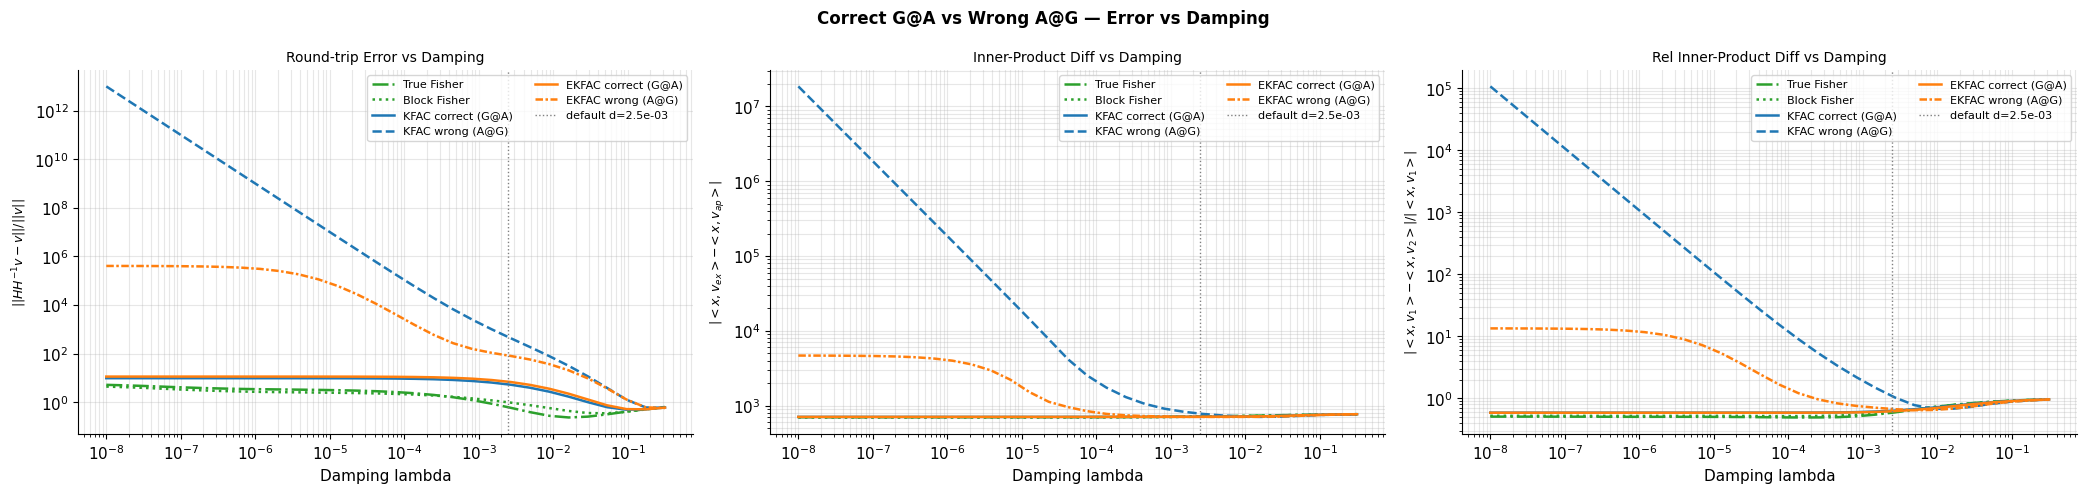

Ordering sensitivity (wrong / correct at default damping):
  KFAC wrong (A@G): 81.90x worse round-trip error
  EKFAC wrong (A@G): 11.81x worse round-trip error


In [75]:
dampings_p4 = np.logspace(-8, -0.5, 30)
curves_rt = {
    nm: []
    for nm in [
        "True Fisher",
        "Block Fisher",
        "KFAC correct (G@A)",
        "KFAC wrong (A@G)",
        "EKFAC correct (G@A)",
        "EKFAC wrong (A@G)",
    ]
}
curves_ip = {nm: [] for nm in curves_rt}
curves_rip = {nm: [] for nm in curves_rt}

ihvp_exact_p4 = inv_ihvp(H_exact_p4, V_p4, 1e-15)
q_p4, ref_q_p4 = V_p4[150:], ihvp_exact_p4[150:]
for d_ in dampings_p4:
    df = float(d_)
    ihs = {
        "True Fisher": inv_ihvp(H_fim_p4, V_p4, df),
        "Block Fisher": inv_ihvp(H_fim_bd_p4, V_p4, df),
        "KFAC correct (G@A)": inv_ihvp(
            kfac_full_matrix(model_p4, A_p4, G_p4), V_p4, df
        ),
        "KFAC wrong (A@G)": inv_ihvp(
            kfac_full_matrix_wrong(model_p4, A_p4, G_p4), V_p4, df
        ),
        "EKFAC correct (G@A)": inv_ihvp(
            ekfac_full_matrix(model_p4, QA_p4, QG_p4, corr_ok_p4), V_p4, df
        ),
        "EKFAC wrong (A@G)": inv_ihvp(
            ekfac_full_matrix_wrong(model_p4, QA_p4, QG_p4, corr_bad_p4), V_p4, df
        ),
    }
    for nm, ih in ihs.items():
        curves_rt[nm].append(round_trip_error(V_p4, ih, H_exact_p4))
        curves_ip[nm].append(vec_inner_product_diff(ref_q_p4, ih[150:], q_p4))
        curves_rip[nm].append(vec_relative_inner_product_diff(ref_q_p4, ih[150:], q_p4))

styles_p4 = {
    "True Fisher": ("-.", "C2"),
    "Block Fisher": (":", "C2"),
    "KFAC correct (G@A)": ("-", "C0"),
    "KFAC wrong (A@G)": ("--", "C0"),
    "EKFAC correct (G@A)": ("-", "C1"),
    "EKFAC wrong (A@G)": ((0, (3, 1, 1, 1)), "C1"),
}

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
fig.suptitle(
    "Correct G@A vs Wrong A@G — Error vs Damping", fontsize=12, fontweight="bold"
)
for ax, data_dict, ylabel, title in [
    (axes[0], curves_rt, r"$||H H^{-1}v-v||/||v||$", "Round-trip Error vs Damping"),
    (axes[1], curves_ip, r"$|<x,v_{ex}>-<x,v_{ap}>|$", "Inner-Product Diff vs Damping"),
    (
        axes[2],
        curves_rip,
        r"$|<x,v_1>-<x,v_2>|/|<x,v_1>|$",
        "Rel Inner-Product Diff vs Damping",
    ),
]:
    for nm, vals in data_dict.items():
        ls, col = styles_p4[nm]
        ax.loglog(dampings_p4, vals, linestyle=ls, color=col, label=nm, linewidth=1.8)
    ax.axvline(d_p4, color="grey", ls=":", lw=1, label=f"default d={d_p4:.1e}")
    ax.set_xlabel("Damping lambda")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3, which="both")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("Ordering sensitivity (wrong / correct at default damping):")
idx_d = np.argmin(np.abs(dampings_p4 - d_p4))
for nm_ok, nm_bad in [
    ("KFAC correct (G@A)", "KFAC wrong (A@G)"),
    ("EKFAC correct (G@A)", "EKFAC wrong (A@G)"),
]:
    ratio = curves_rt[nm_bad][idx_d] / curves_rt[nm_ok][idx_d]
    print(f"  {nm_bad}: {ratio:.2f}x worse round-trip error")

## 4.1 Multi-Seed Pseudo-Inverse Comparison

We repeat the pseudo-inverse round-trip comparison over all seeds to confirm the ordering effect is consistent and not a one-seed artefact.


Running PI ordering comparison across 3 seeds ...
Done.
=== PI Ordering Comparison (Round-Trip Error, mean +/- std) ===
  Method                         Mean RT Error    Std RT Error
  ------------------------------------------------------------
  Exact                                 0.0012          0.0001
  Identity (I)                          0.7856          0.0107
  GNH                                   3.7318          1.4670
  True Fisher                           3.7318          1.4670
  Block Hessian                         1.0595          0.0405
  Block Fisher                          2.7359          0.8817
  KFAC correct (G@A)                    8.5130          0.6461
  KFAC wrong (A@G)                    837.4334        228.2836
  EKFAC correct (G@A)                  10.1499          0.7721
  EKFAC wrong (A@G)                   106.3933         11.6392


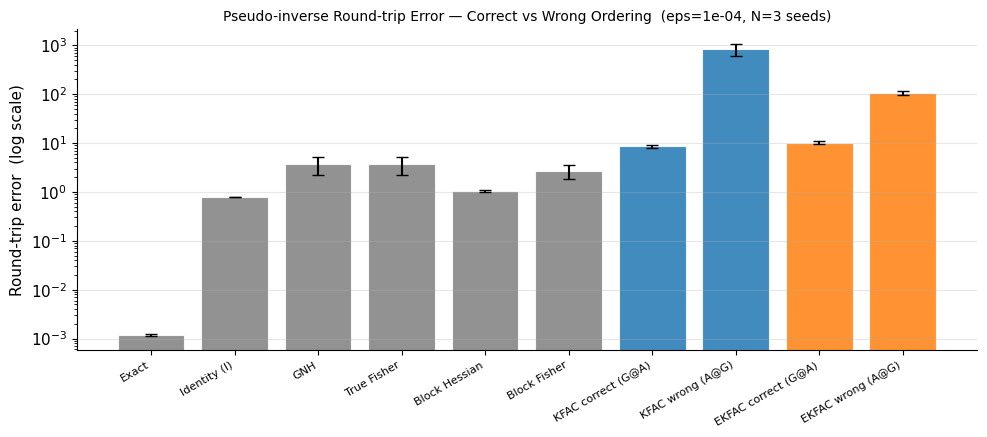

In [76]:
def run_pi_ordering_seed(seed):
    r = results[seed]
    model_s = r["model"]
    H_exact_s, H_gnh_s, H_fim_s = r["H_exact"], r["H_gnh"], r["H_fim"]
    H_bd_s, H_fim_bd_s = r["H_bd"], r["H_fim_bd"]
    A_covs_s, G_covs_s = r["A_covs"], r["G_covs"]
    QA_s, QG_s, corr_ok_s = r["QA"], r["QG"], r["corr"]
    corr_bad_s = compute_ekfac_corrections_wrong(model_s, X_train, QA_s, QG_s)
    torch.manual_seed(seed + 10_000)
    _idx_s = torch.randperm(X_train.shape[0])[:300]
    _rows_s = []
    for _ii in _idx_s:
        model_s.zero_grad()
        F.cross_entropy(
            model_s(X_train[_ii : _ii + 1]), y_train[_ii : _ii + 1]
        ).backward()
        _rows_s.append(
            torch.cat([p.grad.flatten() for p in model_s.parameters()]).detach()
        )
    model_s.zero_grad()
    V_s = torch.stack(_rows_s)
    return {
        "Exact": round_trip_error(V_s, _pi_full(H_exact_s, V_s), H_exact_s),
        "Identity (I)": round_trip_error(V_s, V_s, H_exact_s),
        "GNH": round_trip_error(V_s, _pi_full(H_gnh_s, V_s), H_exact_s),
        "True Fisher": round_trip_error(V_s, _pi_full(H_fim_s, V_s), H_exact_s),
        "Block Hessian": round_trip_error(V_s, _pi_full(H_bd_s, V_s), H_exact_s),
        "Block Fisher": round_trip_error(V_s, _pi_full(H_fim_bd_s, V_s), H_exact_s),
        "KFAC correct (G@A)": round_trip_error(
            V_s, _pi_full(kfac_full_matrix(model_s, A_covs_s, G_covs_s), V_s), H_exact_s
        ),
        "KFAC wrong (A@G)": round_trip_error(
            V_s,
            _pi_full(kfac_full_matrix_wrong(model_s, A_covs_s, G_covs_s), V_s),
            H_exact_s,
        ),
        "EKFAC correct (G@A)": round_trip_error(
            V_s,
            _pi_full(ekfac_full_matrix(model_s, QA_s, QG_s, corr_ok_s), V_s),
            H_exact_s,
        ),
        "EKFAC wrong (A@G)": round_trip_error(
            V_s,
            _pi_full(ekfac_full_matrix_wrong(model_s, QA_s, QG_s, corr_bad_s), V_s),
            H_exact_s,
        ),
    }


print(f"Running PI ordering comparison across {N_SEEDS} seeds ...")
results_pi = [run_pi_ordering_seed(s) for s in range(N_SEEDS)]
print("Done.")

methods_pi = [
    "Exact",
    "Identity (I)",
    "GNH",
    "True Fisher",
    "Block Hessian",
    "Block Fisher",
    "KFAC correct (G@A)",
    "KFAC wrong (A@G)",
    "EKFAC correct (G@A)",
    "EKFAC wrong (A@G)",
]
print("=== PI Ordering Comparison (Round-Trip Error, mean +/- std) ===")
print(f"  {'Method':<28} {'Mean RT Error':>15} {'Std RT Error':>15}")
print("  " + "-" * 60)
for m in methods_pi:
    errs = [r[m] for r in results_pi if m in r]
    if errs:
        print(f"  {m:<28} {np.mean(errs):>15.4f} {np.std(errs):>15.4f}")

bar_colors = ["C7", "C7", "C7", "C7", "C7", "C7", "C0", "C0", "C1", "C1"]
means_pi = [np.mean([r[m] for r in results_pi if m in r]) for m in methods_pi]
stds_pi = [np.std([r[m] for r in results_pi if m in r]) for m in methods_pi]
fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))
ax.set_title(
    f"Pseudo-inverse Round-trip Error — Correct vs Wrong Ordering"
    f"  (eps={EPS:.0e}, N={len(results_pi)} seeds)",
    fontsize=10,
)
ax.bar(
    range(len(methods_pi)),
    means_pi,
    yerr=stds_pi,
    color=bar_colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
    capsize=4,
)
ax.set_xticks(range(len(methods_pi)))
ax.set_xticklabels(methods_pi, rotation=30, ha="right", fontsize=8)
ax.set_yscale("log")
ax.set_ylabel("Round-trip error  (log scale)")
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


In [77]:
print("success")

success
